In [27]:
# !pip install --upgrade pip

In [ ]:
# This is the Alex code for properties (iterates through whole CSD) - WITHOUT filtering
from pathlib import Path

from ccdc.io import EntryReader
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

output_file = Path("filtered.csv")


def csd_iterator():

    csd = EntryReader("csd")

    for entry in csd:
        try:
            mol = entry.molecule
            smiles = mol.smiles
        except RuntimeError:
            continue
        yield mol.identifier, smiles


def _unused_filter(mol):
    mol_id = mol.identifier
    donors = [a for a in mol.atoms if a.is_donor]
    acceptors = [a for a in mol.atoms if a.is_acceptor]

    n_donors = len(donors)
    n_acceptors = len(acceptors)
    weight = mol.molecular_weight


def run():
    """Run the search."""
    records = []
    for i, (identifier, smiles) in enumerate(csd_iterator()):
        if not smiles:
            continue
        mol = Chem.MolFromSmiles(smiles)

        if not mol:
            continue

        logp = Descriptors.MolLogP(mol)
        mol_weight = Descriptors.ExactMolWt(mol)
        hb_donors = Descriptors.NumHDonors(mol)
        hb_acceptors = Descriptors.NumHAcceptors(mol)

        record = {
            "identifier": identifier,
            "logp": logp,
            "mol_weight": mol_weight,
            "hb_donors": hb_donors,
            "hb_acceptors": hb_acceptors,
            "smiles": smiles,
        }
        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(output_file, index=False)


if __name__ == "__main__":
    run()
 

[16:33:35] Explicit valence for atom # 11 O, 3, is greater than permitted
[16:33:36] Explicit valence for atom # 2 C, 5, is greater than permitted
[16:33:36] Explicit valence for atom # 11 O, 3, is greater than permitted
[16:33:36] Explicit valence for atom # 4 N, 4, is greater than permitted
[16:33:36] Explicit valence for atom # 4 N, 4, is greater than permitted
[16:33:36] Explicit valence for atom # 1 Al, 4, is greater than permitted
[16:33:36] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5 8 9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 73 74 75 76 77 78 79 83 84 85 86 87 89 90 91 92 93 94 95 96 97 98 100 101 102 103 104 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 160 161 162 1

[16:33:58] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8
[16:33:59] Explicit valence for atom # 29 Al, 4, is greater than permitted
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23
[16:33:59] Can't kekulize mol.  Unkekulized atoms: 1 2 4 6 8


KeyboardInterrupt: 

In [ ]:
# Same as above but for 1000 entry sample, generates csv filtered but exclused entries without smiles or that couldn't be parsed. 
from ccdc import io

csd = io.EntryReader("CSD")

sample = []
for i, entry in enumerate(csd):
    sample.append(entry)
    if i == 999:
        break

print(len(sample))

###################################################

from pathlib import Path

from ccdc.io import EntryReader
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

output_file = Path("filtered.csv")


def csd_iterator():

    samp = sample

    for entry in samp:
        try:
            mol = entry.molecule
            smiles = mol.smiles
        except RuntimeError:
            continue
        yield mol.identifier, smiles


def _unused_filter(mol):
    mol_id = mol.identifier
    donors = [a for a in mol.atoms if a.is_donor]
    acceptors = [a for a in mol.atoms if a.is_acceptor]

    n_donors = len(donors)
    n_acceptors = len(acceptors)
    weight = mol.molecular_weight


def run():
    """Run the search."""
    records = []
    for i, (identifier, smiles) in enumerate(csd_iterator()):
        if not smiles:
            continue
        mol = Chem.MolFromSmiles(smiles)

        if not mol:
            print(smiles)
            continue

        logp = Descriptors.MolLogP(mol)
        mol_weight = Descriptors.ExactMolWt(mol)
        hb_donors = Descriptors.NumHDonors(mol)
        hb_acceptors = Descriptors.NumHAcceptors(mol)

        record = {
            "identifier": identifier,
            "logp": logp,
            "mol_weight": mol_weight,
            "hb_donors": hb_donors,
            "hb_acceptors": hb_acceptors,
            "smiles": smiles,
        }
        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(output_file, index=False)


if __name__ == "__main__":
    run()
 

1000
O=[U]123(=O)(Oc4ccccc4C4=O1[Ni]15N(CCN1C(=CC(=O25)c1ccccc1O3)C)C(=C4)C)O=S(C)C
CCC12[Cu]3(Oc4ccccc4C=N3C(C)C)C#1(CC)[Cu]12Oc2ccccc2C=N1C(C)C.CCC12[Cu]3(Oc4ccccc4C=N3C(C)C)C#1(CC)[Cu]12Oc2ccccc2C=N1C(C)C
CC(C)N1C(=N(C(C)C)[Ir]1(C#O)C#O)N(C)C
CC(C)(C)N#C[Cu]1O=CC2=CC=CN12
CC(C)(C)N#C[Cu]1O=CC2=CC=CN12
C[Al]1(C)N(c2c(cccc2C(C)C)C(C)C)C(C)(C)c2cccc(n12)c1cccc2ccccc12
c1ccc2n(c1)[Zn+2]1345n6ccccc6c6cc(cc2n16)c1ccc(cc1)c1ccccc1c1ccc(cc1)c1ccc(cc1)c1c2c6ccc(cc6)c6ccc(cc6)c6ccccc6c6ccc(cc6)c6cc7n8c(c6)c6ccccn6[Zn+2]698(n8ccccc78)n7ccccc7c7cc(cc(n67)c6ccccn96)c6ccc(cc6)c6ccccc6c6ccc(cc6)c6ccc(cc6)c6c(c7ccc(cc7)c7ccc(cc7)c7ccccc7c7ccc(cc7)c7cc(n3c(c7)c3ccccn43)c3ccccn53)c3c4ccc(cc4)c4ccc(cc4)c4ccccc4c4ccc(cc4)c4cc5n7c(c4)c4ccccn4[Zn+2]487(n7ccccc7c7cc(cc(n47)c4ccccn84)c4ccc(cc4)c4ccccc4c4ccc(cc4)c4ccc(cc4)c1c1c4ccc(cc4)c4ccc(cc4)c4ccccc4c4ccc(cc4)c4cc7n8c(c4)c4ccccn4[Zn+2]498(n8ccccc78)n7ccccc7c7cc(cc(n47)c4ccccn94)c4ccc(cc4)c4ccccc4c4ccc(cc4)c4ccc(cc4)c3c3c4ccc(cc4)c4ccc(cc4)c4ccccc4c4ccc(

PermissionError: [Errno 13] Permission denied: 'filtered.csv'

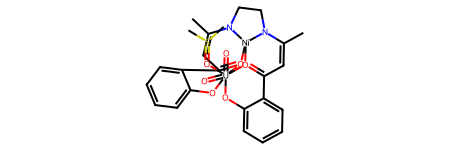

In [9]:
# See why failing molecules are failing. 
failing_mol_1 = Chem.MolFromSmiles("O=[U]123(=O)(Oc4ccccc4C4=O1[Ni]15N(CCN1C(=CC(=O25)c1ccccc1O3)C)C(=C4)C)O=S(C)C", sanitize=False) # Explicit Valence error
failing_mol_1
#cant_kekulize = "C1N2C=CN3Cc4cc5CN6C=CN7CN8C=CN9Cc%10cc%11CN%12C=CN1[C]%12[Pt+]1([C]23)n4n5[Pt+]([C]67)([C]89)n%10n%111.C1N2C=CN3Cc4cc5CN6C=CN7CN8C=CN9Cc%10cc%11CN%12C=CN1[C]%12[Pt+]1([C]23)n4n5[Pt+]([C]67)([C]89)n%10n%111.F[P-](F)(F)(F)(F)F.F[P-](F)(F)(F)(F)F.F[P-](F)(F)(F)(F)F.F[P-](F)(F)(F)(F)F.Cc1ccccc1"
# failing_mols = [Chem.MolFromSmiles(part, sanitize=False) for part in cant_kekulize.split(".")]
# cant_kekulize

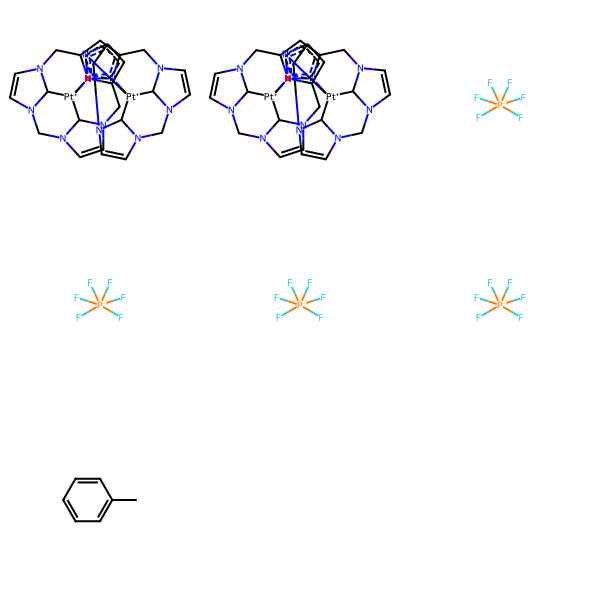

In [7]:
Chem.Draw.MolsToGridImage(failing_mols)

In [1]:
# From first 1000 entries in CSD sample, calculate proportion which fail at each RDkit parsing error or no smiles string error. 

from ccdc import io

csd = io.EntryReader("CSD")

sample = []
for i, entry in enumerate(csd):
    sample.append(entry)
    if i == 999:
        break

print(len(sample))


# classify_rdkit_failures.py
from rdkit import Chem
from rdkit.Chem import rdchem
from rdkit.Chem import rdchem as _rdchem  # alias for exception classes
from rdkit.Chem import rdMolDescriptors
from rdkit import RDLogger
import csv
import traceback
from collections import defaultdict

# Optional: silence RDKit logging to avoid spamming the console
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

OUTPUT_CSV = "sample_smiles_errors.csv"

# Helper: readable sanitise flags
from rdkit.Chem import SanitizeFlags

# Categories we will produce
# 'success' - parsed fine
# 'none_returned' - MolFromSmiles returned None even with sanitize=False
# 'valence' - explicit valence error found
# 'kekulize' - kekulization/aromaticity problem
# 'parse_failed' - general parse fail / MolFromSmiles returned None (fast path)
# 'partial_sanitize_ok' - sanitize failed but succeeded when skipping kekulize (we treat as kekulize-related)
# 'other_sanitize_error' - some other sanitize error (e.g. aromaticity, radicals)
# 'unexpected_exception' - unexpected exception (traceback saved)

def classify_smiles(smiles):
    """
    Return (category, message, mol_or_none)
    """
    if not smiles:
        return "empty_smiles", "empty or missing SMILES", None

    # Fast path
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return "success", "parsed_and_sanitized", mol

    # Fallback: parse without sanitize, then try stepwise sanitization to get an informative error
    try:
        mol = Chem.MolFromSmiles(smiles, sanitize=False)
    except Exception as e_parse:
        return "parse_exception", f"MolFromSmiles(sanitize=False) raised: {e_parse}", None

    if mol is None:
        return "none_returned", "MolFromSmiles returned None (sanitize=False)", None

    # Try full sanitize and inspect exception message if it fails
    try:
        Chem.SanitizeMol(mol)  # full sanitize (may raise)
        return "success_after_fallback", "parsed_with sanitize=False then sanitized", mol
    except Exception as e_full:
        msg = str(e_full) or repr(e_full)
        mlow = msg.lower()

        # Common textual heuristics
        if "explicit valence" in mlow or "valence" in mlow:
            return "valence", msg, None
        if "kekul" in mlow or "kekulize" in mlow:
            # Try sanitizing while skipping kekulization to see if everything else is OK
            try:
                flags_no_kek = SanitizeFlags.SANITIZE_ALL ^ SanitizeFlags.SANITIZE_KEKULIZE
                Chem.SanitizeMol(mol, sanitizeOps=flags_no_kek)
                # If we reached here, everything except kekulize succeeded
                return "kekulize", msg, mol
            except Exception as e_partial:
                # still failing: record combined message
                return "kekulize_and_other", f"{msg} | partial_sanitize_error: {e_partial}", None

        # Try skipping kekulize generically to detect aromatic-only problems
        try:
            flags_no_kek = SanitizeFlags.SANITIZE_ALL ^ SanitizeFlags.SANITIZE_KEKULIZE
            Chem.SanitizeMol(mol, sanitizeOps=flags_no_kek)
            return "partial_sanitize_ok_no_kekulize", f"{msg} | sanitized OK without kekulize", mol
        except Exception as e_partial:
            partial_msg = str(e_partial) or repr(e_partial)
            # Heuristic checks for common other messages
            if "aromatic" in mlow or "aromaticity" in mlow:
                return "aromaticity", msg + " | " + partial_msg, None
            if "radical" in mlow:
                return "radical", msg + " | " + partial_msg, None

            # Generic fallback: record the sanitize exception text
            return "other_sanitize_error", f"{msg} | partial_sanitize: {partial_msg}", None
    except Exception as e_unexp:
        tb = traceback.format_exc()
        return "unexpected_exception", tb, None

def analyze_sample(sample_list):
    counts = defaultdict(int)
    details = []

    for entry in sample_list:
        identifier = getattr(entry, "identifier", None)
        smiles = None
        try:
            molobj = entry.molecule  # may raise RuntimeError on bad entry
            smiles = molobj.smiles if molobj and getattr(molobj, "smiles", None) else None
        except Exception as e:
            # CCDC entry access failure - treat as separate category
            cat = "ccdc_entry_error"
            msg = f"CCDC entry access error: {e}"
            counts[cat] += 1
            details.append((identifier, smiles, cat, msg))
            continue

        cat, msg, mol_or_none = classify_smiles(smiles)
        counts[cat] += 1
        details.append((identifier, smiles, cat, msg))

    # Write the error CSV (including successes if you want to inspect them)
    with open(OUTPUT_CSV, "w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(["identifier", "smiles", "category", "message"])
        for identifier, smiles, cat, msg in details:
            writer.writerow([identifier, smiles, cat, msg])

    # Print summary sorted by frequency
    total = len(sample_list)
    print(f"Analyzed {total} entries. Summary (count, percent):")
    for cat, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        pct = cnt / total * 100
        print(f"  {cat:30s} {cnt:6d}   {pct:5.2f}%")

    return counts, details

# Run it
if __name__ == "__main__":
    # replace `sample` with the actual variable name if different; here we assume `sample` (list of entries) exists
    try:
        counts, details = analyze_sample(sample)
        print(f"Wrote detailed results to {OUTPUT_CSV}")
    except NameError:
        print("Error: variable 'sample' not found. Please run this where `sample` is defined (a list of CSD entry objects).")


1000
Analyzed 1000 entries. Summary (count, percent):
  success                           660   66.00%
  empty_smiles                      130   13.00%
  valence                           105   10.50%
  kekulize                          103   10.30%
  none_returned                       2    0.20%
Wrote detailed results to sample_smiles_errors.csv
